In [54]:
import pandas as pd
import numpy as np

# If you uploaded files via Colab "Files" sidebar, these names should match exactly:
WEATHER_PATH = "data/pakistan_city_weather_daily.csv"
POP_DENSITY_PATH = "data/API_EN.POP.DNST_DS2_en_csv_v2_110190.csv"
URBAN_PCT_PATH = "data/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_110318.csv"
SURFACE_TEMP_PATH = "data/average-monthly-surface-temperature.csv"


In [55]:
# 1) City daily weather
weather = pd.read_csv(WEATHER_PATH)

# 2) World Bank files have 4 metadata rows
pop = pd.read_csv(POP_DENSITY_PATH, skiprows=4)
urban = pd.read_csv(URBAN_PCT_PATH, skiprows=4)

# 3) Monthly surface temperature (OWID style)
surf = pd.read_csv(SURFACE_TEMP_PATH)

print("weather:", weather.shape)
print("pop:", pop.shape)
print("urban:", urban.shape)
print("surf:", surf.shape)

display(weather.head())


weather: (157957, 12)
pop: (266, 70)
urban: (266, 70)
surf: (219603, 4)


,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,city
0,1961-01-13,15.7,7.2,22.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Karachi
1,1961-01-14,16.7,8.3,25.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Karachi
2,1961-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Karachi
3,1961-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Karachi
4,1961-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Karachi


In [56]:
weather = weather.copy()

# Parse date
weather["time"] = pd.to_datetime(weather["time"], errors="coerce")
weather = weather.dropna(subset=["time", "city"])

# Add year/month
weather["year"] = weather["time"].dt.year
weather["month"] = weather["time"].dt.month

# Monthly aggregation
agg = {
    "tavg": ["mean", "max"],
    "tmin": ["mean", "min"],
    "tmax": ["mean", "max"],
    "prcp": ["sum", "mean"],
    "wspd": ["mean", "max"],
    "pres": ["mean"],
    "tsun": ["mean", "sum"],
}
monthly = weather.groupby(["city","year","month"]).agg(agg)
monthly.columns = ["_".join([a,b]) for a,b in monthly.columns]
monthly = monthly.reset_index()

# Observations per month (quality signal)
monthly["n_days"] = weather.groupby(["city","year","month"]).size().values

print("monthly city-month table:", monthly.shape)
display(monthly.head())


monthly city-month table: (5197, 17)


,city,year,month,tavg_mean,tavg_max,tmin_mean,tmin_min,tmax_mean,tmax_max,prcp_sum,prcp_mean,wspd_mean,wspd_max,pres_mean,tsun_mean,tsun_sum,n_days
0,Faisalabad,2011,11,21.05,21.3,NaN,NaN,NaN,NaN,0.0,NaN,1.15,1.4,NaN,NaN,0.0,17
1,Faisalabad,2011,12,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,31
2,Faisalabad,2012,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,31
3,Faisalabad,2012,2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,29
4,Faisalabad,2012,3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,31


In [57]:
coverage = monthly.groupby("city").agg(
    start_year=("year","min"),
    end_year=("year","max"),
    n_months=("year","size"),
    pct_tavg_nonnull=("tavg_mean", lambda s: s.notna().mean())
).sort_values("n_months", ascending=False)

display(coverage.head(20))

# Keep cities with strong coverage (tweak thresholds if needed)
good_cities = coverage[(coverage["n_months"] >= 600) & (coverage["pct_tavg_nonnull"] >= 0.80)].index.tolist()
print("Good cities:", good_cities)

monthly = monthly[monthly["city"].isin(good_cities)].copy()
print("After filtering:", monthly.shape)


,start_year,end_year,n_months,pct_tavg_nonnull
city,,,,
Lahore,1961,2025,780,0.819231
Karachi,1961,2025,780,0.812821
Peshawar,1961,2025,780,0.802564
Multan,1961,2025,779,0.807445
Quetta,1973,2025,636,0.891509
Islamabad,1973,2025,636,0.959119
Rawalpindi,1973,2025,636,0.959119
Faisalabad,2011,2025,170,0.370588


Good cities: ['Lahore', 'Karachi', 'Peshawar', 'Multan', 'Quetta', 'Islamabad', 'Rawalpindi']
After filtering: (5027, 17)


In [58]:
def wb_to_long(df, country_code="PAK", value_name="value"):
    d = df[df["Country Code"] == country_code].copy()
    year_cols = [c for c in d.columns if c.isdigit()]
    d = d[["Country Code"] + year_cols]
    out = d.melt(id_vars=["Country Code"], value_vars=year_cols, var_name="year", value_name=value_name)
    out["year"] = out["year"].astype(int)
    out = out.dropna(subset=[value_name])
    return out[["year", value_name]]

pop_pak = wb_to_long(pop, "PAK", "pop_density")
urb_pak = wb_to_long(urban, "PAK", "urban_pct")

display(pop_pak.head())
display(urb_pak.head())


,year,pop_density
1,1961,60.867161
2,1962,62.469033
3,1963,64.144583
4,1964,65.898712
5,1965,67.726507


,year,urban_pct
0,1960,22.104
1,1961,22.501
2,1962,22.751
3,1963,23.002
4,1964,23.256


In [59]:
surf_pak = surf[surf["Code"] == "PAK"].copy()
surf_pak["Day"] = pd.to_datetime(surf_pak["Day"], errors="coerce")
surf_pak = surf_pak.dropna(subset=["Day"])

surf_pak["year"] = surf_pak["Day"].dt.year
surf_pak["month"] = surf_pak["Day"].dt.month

surf_pak = surf_pak.rename(columns={"Average surface temperature": "surface_temp_avg"})
surf_pak = surf_pak[["year","month","surface_temp_avg"]].copy()

display(surf_pak.head())


,year,month,surface_temp_avg
151557,1940,1,9.082222
151558,1940,2,11.003629
151559,1940,3,14.157861
151560,1940,4,20.374487
151561,1940,5,27.040268


In [60]:
df = monthly.merge(pop_pak, on="year", how="left") \
           .merge(urb_pak, on="year", how="left") \
           .merge(surf_pak, on=["year","month"], how="left")

print("Merged df:", df.shape)
print(df.isna().mean().sort_values(ascending=False).head(15))
display(df.head())


Merged df: (5027, 20)
tsun_mean           1.000000
pres_mean           0.845833
wspd_max            0.623235
wspd_mean           0.623235
prcp_mean           0.265964
tmin_mean           0.177442
tmin_min            0.177442
tavg_mean           0.141635
tavg_max            0.141635
tmax_max            0.141635
tmax_mean           0.141635
pop_density         0.033420
urban_pct           0.016710
surface_temp_avg    0.001392
city                0.000000
dtype: float64


,city,year,month,tavg_mean,tavg_max,tmin_mean,tmin_min,tmax_mean,tmax_max,prcp_sum,prcp_mean,wspd_mean,wspd_max,pres_mean,tsun_mean,tsun_sum,n_days,pop_density,urban_pct,surface_temp_avg
0,Islamabad,1973,1,10.728571,13.0,6.25,6.0,16.285714,19.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,28,84.918421,25.671,6.722661
1,Islamabad,1973,2,13.700000,18.5,5.00,3.0,20.600000,34.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,28,84.918421,25.671,12.587411
2,Islamabad,1973,3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,31,84.918421,25.671,16.396318
3,Islamabad,1973,4,25.560000,30.8,18.00,14.0,31.000000,38.0,2.0,0.666667,NaN,NaN,NaN,NaN,0.0,30,84.918421,25.671,23.321028
4,Islamabad,1973,5,25.200000,31.4,24.00,24.0,29.500000,36.0,0.0,0.000000,NaN,NaN,NaN,NaN,0.0,31,84.918421,25.671,27.186968


In [61]:
df = df.sort_values(["city","year","month"]).copy()

# Seasonality encoding
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

# City-month climatology baseline (long-run average by city + month)
clim = df.groupby(["city","month"])["tavg_mean"].mean().rename("tavg_clim")
df = df.merge(clim, on=["city","month"], how="left")

# Temperature anomaly vs city’s own baseline
df["tavg_anom"] = df["tavg_mean"] - df["tavg_clim"]

# Quick missing handling (only for key predictors)
df = df.dropna(subset=["tavg_mean", "tmax_mean", "pop_density", "urban_pct", "surface_temp_avg"])

print("After dropping key missing:", df.shape)
display(df.head())


After dropping key missing: (4147, 24)


,city,year,month,tavg_mean,tavg_max,tmin_mean,tmin_min,tmax_mean,tmax_max,prcp_sum,...,tsun_mean,tsun_sum,n_days,pop_density,urban_pct,surface_temp_avg,month_sin,month_cos,tavg_clim,tavg_anom
0,Islamabad,1973,1,10.728571,13.0,6.25,6.0,16.285714,19.0,0.0,...,NaN,0.0,28,84.918421,25.671,6.722661,0.500000,8.660254e-01,10.385781,0.342790
1,Islamabad,1973,2,13.700000,18.5,5.00,3.0,20.600000,34.0,0.0,...,NaN,0.0,28,84.918421,25.671,12.587411,0.866025,5.000000e-01,13.159320,0.540680
3,Islamabad,1973,4,25.560000,30.8,18.00,14.0,31.000000,38.0,2.0,...,NaN,0.0,30,84.918421,25.671,23.321028,0.866025,-5.000000e-01,23.712838,1.847162
4,Islamabad,1973,5,25.200000,31.4,24.00,24.0,29.500000,36.0,0.0,...,NaN,0.0,31,84.918421,25.671,27.186968,0.500000,-8.660254e-01,28.952477,-3.752477
8,Islamabad,1973,9,27.300000,27.3,19.00,19.0,33.000000,33.0,16.0,...,NaN,0.0,30,84.918421,25.671,25.655409,-1.000000,-1.836970e-16,27.357948,-0.057948


In [62]:
df.to_csv("processed_city_month_heat_features.csv", index=False)
print("Saved:", "processed_city_month_heat_features.csv")


Saved: processed_city_month_heat_features.csv


In [63]:
df = df.copy()

# Normalize key components (city-agnostic scaling)
def zscore(s):
    return (s - s.mean()) / s.std()

df["tavg_z"] = zscore(df["tavg_mean"])
df["tmax_z"] = zscore(df["tmax_mean"])
df["surf_z"] = zscore(df["surface_temp_avg"])
df["pop_z"]  = zscore(df["pop_density"])
df["urb_z"]  = zscore(df["urban_pct"])

# Wind reduces heat stress → subtract
df["wspd_mean_filled"] = df["wspd_mean"].fillna(df["wspd_mean"].median())
df["wind_z"] = zscore(df["wspd_mean_filled"])

# Heat Stress Index (proxy)
df["heat_stress_index"] = (
    0.40 * df["tavg_z"] +
    0.30 * df["tmax_z"] +
    0.15 * df["surf_z"] +
    0.10 * df["pop_z"] +
    0.10 * df["urb_z"] -
    0.05 * df["wind_z"]
)

df[["city","year","month","heat_stress_index"]].head()


,city,year,month,heat_stress_index
0,Islamabad,1973,1,-1.779406
1,Islamabad,1973,2,-1.333574
3,Islamabad,1973,4,-0.090771
4,Islamabad,1973,5,-0.091300
8,Islamabad,1973,9,0.126397


In [64]:
# Percentile thresholds
p50 = df["heat_stress_index"].quantile(0.50)
p75 = df["heat_stress_index"].quantile(0.75)
p90 = df["heat_stress_index"].quantile(0.90)

def risk_label(x):
    if x <= p50:
        return 0   # Low
    elif x <= p75:
        return 1   # Moderate
    elif x <= p90:
        return 2   # High
    else:
        return 3   # Extreme

df["risk_label"] = df["heat_stress_index"].apply(risk_label)

df["risk_label"].value_counts().sort_index()


,count
risk_label,
0,2074
1,1036
2,622
3,415


In [65]:
df = df.sort_values(["city","year","month"]).copy()

for lag in [1, 3, 6]:
    df[f"heat_lag_{lag}"] = df.groupby("city")["heat_stress_index"].shift(lag)
    df[f"risk_lag_{lag}"] = df.groupby("city")["risk_label"].shift(lag)

df.head()


,city,year,month,tavg_mean,tavg_max,tmin_mean,tmin_min,tmax_mean,tmax_max,prcp_sum,...,wspd_mean_filled,wind_z,heat_stress_index,risk_label,heat_lag_1,risk_lag_1,heat_lag_3,risk_lag_3,heat_lag_6,risk_lag_6
0,Islamabad,1973,1,10.728571,13.0,6.25,6.0,16.285714,19.0,0.0,...,9.790077,-0.054397,-1.779406,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Islamabad,1973,2,13.700000,18.5,5.00,3.0,20.600000,34.0,0.0,...,9.790077,-0.054397,-1.333574,0,-1.779406,0.0,NaN,NaN,NaN,NaN
3,Islamabad,1973,4,25.560000,30.8,18.00,14.0,31.000000,38.0,2.0,...,9.790077,-0.054397,-0.090771,0,-1.333574,0.0,NaN,NaN,NaN,NaN
4,Islamabad,1973,5,25.200000,31.4,24.00,24.0,29.500000,36.0,0.0,...,9.790077,-0.054397,-0.091300,0,-0.090771,0.0,-1.779406,0.0,NaN,NaN
8,Islamabad,1973,9,27.300000,27.3,19.00,19.0,33.000000,33.0,16.0,...,9.790077,-0.054397,0.126397,0,-0.091300,0.0,-1.333574,0.0,NaN,NaN


In [66]:
for w in [3, 6]:
    df[f"heat_roll_mean_{w}"] = (
        df.groupby("city")["heat_stress_index"]
          .shift(1)
          .rolling(w)
          .mean()
    )
    df[f"heat_roll_std_{w}"] = (
        df.groupby("city")["heat_stress_index"]
          .shift(1)
          .rolling(w)
          .std()
    )

df.head()


,city,year,month,tavg_mean,tavg_max,tmin_mean,tmin_min,tmax_mean,tmax_max,prcp_sum,...,heat_lag_1,risk_lag_1,heat_lag_3,risk_lag_3,heat_lag_6,risk_lag_6,heat_roll_mean_3,heat_roll_std_3,heat_roll_mean_6,heat_roll_std_6
0,Islamabad,1973,1,10.728571,13.0,6.25,6.0,16.285714,19.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Islamabad,1973,2,13.700000,18.5,5.00,3.0,20.600000,34.0,0.0,...,-1.779406,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Islamabad,1973,4,25.560000,30.8,18.00,14.0,31.000000,38.0,2.0,...,-1.333574,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Islamabad,1973,5,25.200000,31.4,24.00,24.0,29.500000,36.0,0.0,...,-0.090771,0.0,-1.779406,0.0,NaN,NaN,-1.067917,0.875101,NaN,NaN
8,Islamabad,1973,9,27.300000,27.3,19.00,19.0,33.000000,33.0,16.0,...,-0.091300,0.0,-1.333574,0.0,NaN,NaN,-0.505215,0.717380,NaN,NaN


In [67]:
feature_cols = [
    # Climate
    "tavg_mean", "tmax_mean", "tavg_anom",
    "surface_temp_avg",

    # Urban vulnerability
    "pop_density", "urban_pct",

    # Seasonality
    "month_sin", "month_cos",

    # Lags
    "heat_lag_1", "heat_lag_3", "heat_lag_6",
    "risk_lag_1", "risk_lag_3", "risk_lag_6",

    # Rolling
    "heat_roll_mean_3", "heat_roll_std_3",
    "heat_roll_mean_6", "heat_roll_std_6",
]

df_model = df.dropna(subset=feature_cols + ["risk_label"]).copy()

X = df_model[feature_cols]
y = df_model["risk_label"]

print("Final ML table:", X.shape)
print(y.value_counts(normalize=True))


Final ML table: (4105, 18)
risk_label
0    0.497199
1    0.250426
2    0.151279
3    0.101096
Name: proportion, dtype: float64


In [68]:
# Holdout by year
train = df_model[df_model["year"] <= 2015]
val   = df_model[(df_model["year"] > 2015) & (df_model["year"] <= 2019)]
test  = df_model[df_model["year"] > 2019]

X_train, y_train = train[feature_cols], train["risk_label"]
X_val,   y_val   = val[feature_cols],   val["risk_label"]
X_test,  y_test  = test[feature_cols],  test["risk_label"]

X_train.shape, X_val.shape, X_test.shape


((3475, 18), (306, 18), (324, 18))

In [69]:
# Baseline: predict next risk = previous month risk
baseline_pred = test["risk_lag_1"]

from sklearn.metrics import f1_score, accuracy_score

baseline_f1 = f1_score(y_test, baseline_pred, average="macro")
baseline_acc = accuracy_score(y_test, baseline_pred)

baseline_f1, baseline_acc


(0.5117176320400176, 0.5679012345679012)

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import numpy as np


In [71]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="multinomial"
    ))
])

log_reg.fit(X_train, y_train)

log_val_pred = log_reg.predict(X_val)
log_test_pred = log_reg.predict(X_test)

log_f1 = f1_score(y_test, log_test_pred, average="macro")
log_acc = accuracy_score(y_test, log_test_pred)

log_f1, log_acc


(0.9152894056847545, 0.9290123456790124)

In [72]:
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

dt_test_pred = dt.predict(X_test)

dt_f1 = f1_score(y_test, dt_test_pred, average="macro")
dt_acc = accuracy_score(y_test, dt_test_pred)

dt_f1, dt_acc


(0.7418793753324371, 0.7870370370370371)

In [73]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=15,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_test_pred = rf.predict(X_test)

rf_f1 = f1_score(y_test, rf_test_pred, average="macro")
rf_acc = accuracy_score(y_test, rf_test_pred)

rf_f1, rf_acc


(0.7371122239559551, 0.7870370370370371)

In [74]:
gb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

gb.fit(X_train, y_train)

gb_test_pred = gb.predict(X_test)

gb_f1 = f1_score(y_test, gb_test_pred, average="macro")
gb_acc = accuracy_score(y_test, gb_test_pred)

gb_f1, gb_acc


(0.7735996051410863, 0.8148148148148148)

In [75]:
results = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Macro F1": [
        baseline_f1,
        log_f1,
        dt_f1,
        rf_f1,
        gb_f1
    ],
    "Accuracy": [
        baseline_acc,
        log_acc,
        dt_acc,
        rf_acc,
        gb_acc
    ]
})

results.sort_values("Macro F1", ascending=False)


,Model,Macro F1,Accuracy
1,Logistic Regression,0.915289,0.929012
4,Gradient Boosting,0.773600,0.814815
2,Decision Tree,0.741879,0.787037
3,Random Forest,0.737112,0.787037
0,Persistence Baseline,0.511718,0.567901


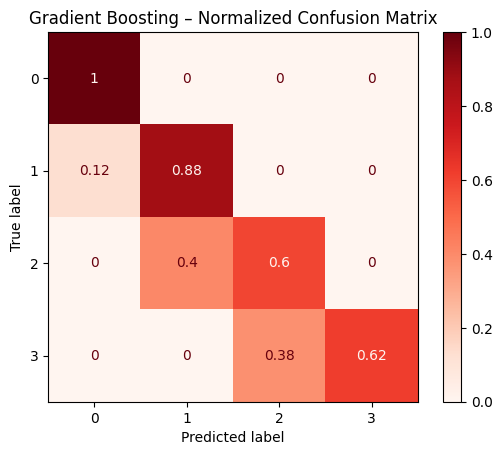

In [76]:
best_model = gb   # change if RF performs better

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_test_pred,
    cmap="Reds",
    normalize="true"
)

plt.title("Gradient Boosting – Normalized Confusion Matrix")
plt.show()


In [77]:
test_errors = test.copy()
test_errors["pred"] = gb_test_pred
test_errors["correct"] = test_errors["pred"] == test_errors["risk_label"]

# Where model fails most
error_summary = (
    test_errors[~test_errors["correct"]]
    .groupby("city")
    .size()
    .sort_values(ascending=False)
)

error_summary


,0
city,
Islamabad,12
Rawalpindi,12
Karachi,8
Lahore,8
Multan,8
Peshawar,7
Quetta,5


In [78]:
importances = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importances.head(10)


,0
tavg_mean,0.265620
tmax_mean,0.218440
surface_temp_avg,0.091651
heat_lag_1,0.073056
month_cos,0.067339
pop_density,0.054861
urban_pct,0.051864
risk_lag_1,0.027721
heat_roll_mean_3,0.027215
heat_lag_6,0.026694


In [79]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    gb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

perm_importance.head(10)


,0
tmax_mean,0.149074
tavg_mean,0.140432
surface_temp_avg,0.008951
heat_lag_1,0.008333
heat_roll_mean_3,0.006790
heat_roll_std_3,0.004012
heat_roll_std_6,0.002160
heat_lag_6,0.001543
urban_pct,0.000000
pop_density,0.000000


In [80]:
# Full features you used (keep)
feature_cols_full = feature_cols.copy()

# Climate-driven features (NO risk_lag_*)
feature_cols_climate = [c for c in feature_cols_full if not c.startswith("risk_lag_")]

print("Full feature count:", len(feature_cols_full))
print("Climate-only feature count:", len(feature_cols_climate))
print("Removed:", sorted(set(feature_cols_full) - set(feature_cols_climate)))


Full feature count: 18
Climate-only feature count: 15
Removed: ['risk_lag_1', 'risk_lag_3', 'risk_lag_6']


In [81]:
X_train_c = train[feature_cols_climate]
X_val_c   = val[feature_cols_climate]
X_test_c  = test[feature_cols_climate]

y_train = train["risk_label"]
y_val   = val["risk_label"]
y_test  = test["risk_label"]

X_train_c.shape, X_val_c.shape, X_test_c.shape


((3475, 15), (306, 15), (324, 15))

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

log_reg_c = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

log_reg_c.fit(X_train_c, y_train)

log_pred_c = log_reg_c.predict(X_test_c)

log_f1_c = f1_score(y_test, log_pred_c, average="macro")
log_acc_c = accuracy_score(y_test, log_pred_c)

log_f1_c, log_acc_c


(0.9114454379864216, 0.9259259259259259)

In [83]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_c = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

gb_c.fit(X_train_c, y_train)

gb_pred_c = gb_c.predict(X_test_c)

gb_f1_c = f1_score(y_test, gb_pred_c, average="macro")
gb_acc_c = accuracy_score(y_test, gb_pred_c)

gb_f1_c, gb_acc_c


(0.7848597836498418, 0.8240740740740741)

In [84]:
results_fix = pd.DataFrame({
    "Model": [
        "Persistence Baseline (risk_lag_1)",
        "LogReg (with risk_lags) [Monitoring]",
        "GB (with risk_lags) [Monitoring]",
        "LogReg (climate-only) [Forecast]",
        "GB (climate-only) [Forecast]"
    ],
    "Macro F1": [
        baseline_f1,
        log_f1,
        gb_f1,
        log_f1_c,
        gb_f1_c
    ],
    "Accuracy": [
        baseline_acc,
        log_acc,
        gb_acc,
        log_acc_c,
        gb_acc_c
    ]
})

results_fix


,Model,Macro F1,Accuracy
0,Persistence Baseline (risk_lag_1),0.511718,0.567901
1,LogReg (with risk_lags) [Monitoring],0.915289,0.929012
2,GB (with risk_lags) [Monitoring],0.773600,0.814815
3,LogReg (climate-only) [Forecast],0.911445,0.925926
4,GB (climate-only) [Forecast],0.784860,0.824074


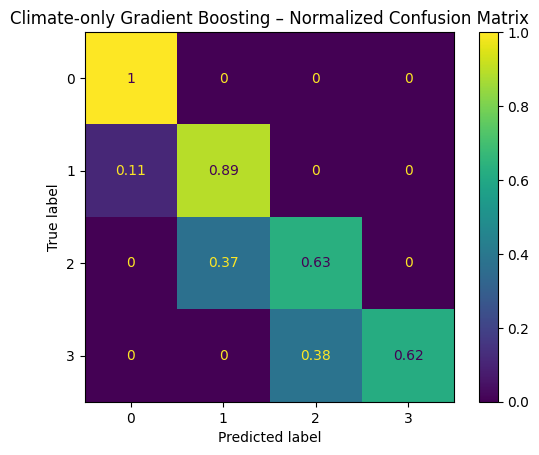

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, gb_pred_c,
    normalize="true"
)
plt.title("Climate-only Gradient Boosting – Normalized Confusion Matrix")
plt.show()


In [86]:
from sklearn.ensemble import RandomForestClassifier

rf_c = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=15,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf_c.fit(X_train_c, y_train)

rf_pred_c = rf_c.predict(X_test_c)

rf_f1_c = f1_score(y_test, rf_pred_c, average="macro")
rf_acc_c = accuracy_score(y_test, rf_pred_c)

rf_f1_c, rf_acc_c


(0.7409759355336892, 0.7901234567901234)

In [87]:
imp_c = pd.Series(rf_c.feature_importances_, index=feature_cols_climate).sort_values(ascending=False)
imp_c.head(15)


,0
tavg_mean,0.252301
tmax_mean,0.217554
surface_temp_avg,0.108604
heat_lag_1,0.085257
month_cos,0.060099
pop_density,0.051760
urban_pct,0.050870
heat_lag_6,0.033607
heat_roll_mean_3,0.032748
heat_roll_std_3,0.027754


In [89]:
import shap
import numpy as np

X_shap = X_test_c.sample(min(300, len(X_test_c)), random_state=42)

explainer = shap.TreeExplainer(rf_c)
sv = explainer.shap_values(X_shap)

print("Type:", type(sv))
if isinstance(sv, list):
    print("List length (classes):", len(sv))
    print("Class 0 shape:", np.array(sv[0]).shape)
else:
    print("Array shape:", np.array(sv).shape)

print("X_shap shape:", X_shap.shape)


Type: <class 'numpy.ndarray'>
Array shape: (300, 15, 4)
X_shap shape: (300, 15)


sv_c shape: (300, 15) expected: (300, 15)


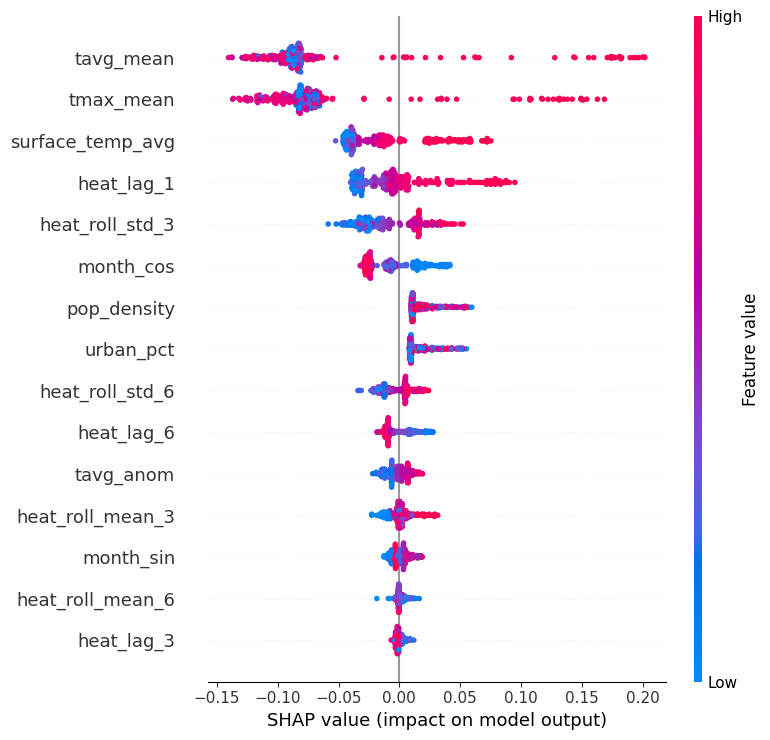

In [90]:
import matplotlib.pyplot as plt

# Choose which class to explain: 3 = Extreme (your label scheme)
CLASS_IDX = 3

# Convert sv -> (n_samples, n_features) for selected class
if isinstance(sv, list):
    sv_c = np.array(sv[CLASS_IDX])
else:
    arr = np.array(sv)
    # Common formats:
    # (n_samples, n_features, n_classes) OR (n_classes, n_samples, n_features)
    if arr.ndim == 3:
        if arr.shape[0] == X_shap.shape[0] and arr.shape[1] == X_shap.shape[1]:
            sv_c = arr[:, :, CLASS_IDX]          # (samples, features, classes)
        elif arr.shape[1] == X_shap.shape[0] and arr.shape[2] == X_shap.shape[1]:
            sv_c = arr[CLASS_IDX, :, :]          # (classes, samples, features)
        else:
            raise ValueError(f"Unhandled SHAP array shape: {arr.shape}")
    else:
        raise ValueError(f"Unhandled SHAP output ndim: {arr.ndim}")

print("sv_c shape:", sv_c.shape, "expected:", X_shap.shape)

shap.summary_plot(sv_c, X_shap, show=True)


Explanation values shape: (300, 15, 4)


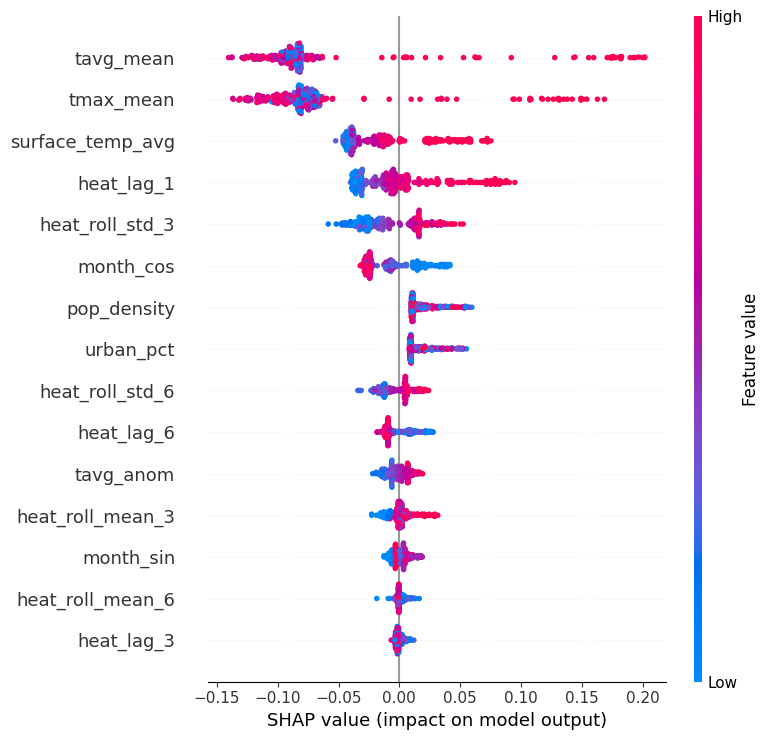

In [91]:
# Newer SHAP returns an Explanation object via calling explainer directly
exp = explainer(X_shap)

print("Explanation values shape:", exp.values.shape)  # often (n_samples, n_features, n_classes)

# If multiclass, slice class dimension
vals = exp.values
if vals.ndim == 3:
    vals = vals[:, :, 3]  # class 3 = Extreme

shap.summary_plot(vals, X_shap, show=True)


City: Lahore Year-Month: 2022 4


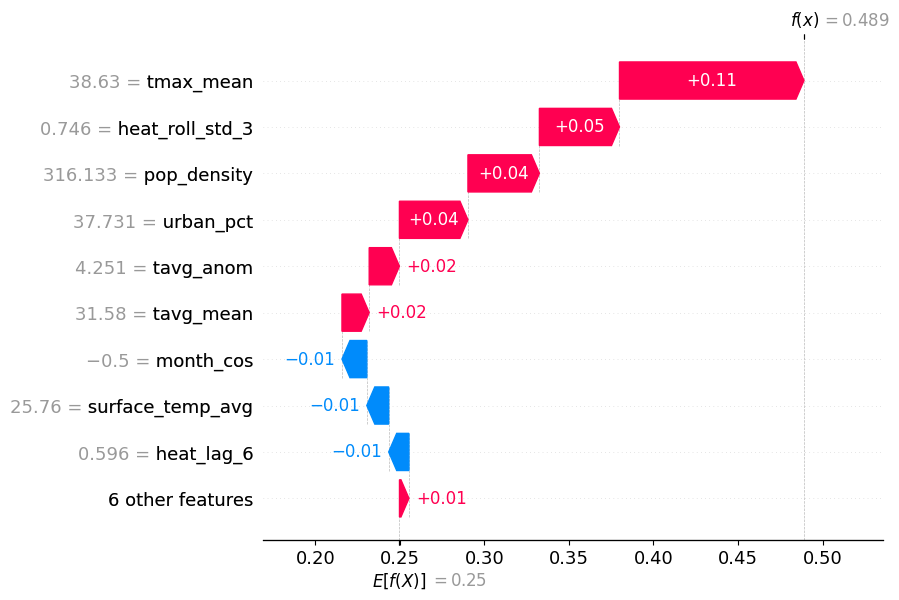

In [93]:
# Pick a single row for a city (e.g., Lahore) from TEST
city_name = "Lahore"
subset = test[test["city"] == city_name]
if len(subset) == 0:
    print("No rows for", city_name, "in test split.")
else:
    row = subset.sample(1, random_state=42)
    x_row = row[feature_cols_climate]

    # Use new Explanation-style (most reliable)
    exp1 = explainer(x_row)
    vals = exp1.values
    base = exp1.base_values

    if vals.ndim == 3:          # (1, features, classes)
        vals_c = vals[0, :, 3]  # Extreme
        base_c = base[0, 3]
    else:
        vals_c = vals[0]
        base_c = base[0]

    print("City:", row["city"].values[0], "Year-Month:", row["year"].values[0], row["month"].values[0])
    shap.plots.waterfall(shap.Explanation(values=vals_c, base_values=base_c, data=x_row.iloc[0], feature_names=feature_cols_climate))


In [95]:
import pandas as pd
import numpy as np

MODEL = gb_c  # your climate-only Gradient Boosting (main forecast model)

CITIES = sorted(df_model["city"].unique().tolist())
print("Cities:", CITIES)

# We need means/stds for z-scores used in heat_stress_index formula
stats = {
    "tavg_mean": (df["tavg_mean"].mean(), df["tavg_mean"].std()),
    "tmax_mean": (df["tmax_mean"].mean(), df["tmax_mean"].std()),
    "surface_temp_avg": (df["surface_temp_avg"].mean(), df["surface_temp_avg"].std()),
    "pop_density": (df["pop_density"].mean(), df["pop_density"].std()),
    "urban_pct": (df["urban_pct"].mean(), df["urban_pct"].std()),
    "wspd_mean_filled": (df["wspd_mean_filled"].mean(), df["wspd_mean_filled"].std()),
}
stats


Cities: ['Islamabad', 'Karachi', 'Lahore', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi']


{'tavg_mean': (np.float64(23.06628832960444), 7.910545373856214),
 'tmax_mean': (np.float64(29.794234964874025), 7.355593022547068),
 'surface_temp_avg': (np.float64(20.32984294236798), 7.354141437553511),
 'pop_density': (np.float64(193.46756702939243), 73.17365803374881),
 'urban_pct': (np.float64(32.14733301181577), 3.569617659998036),
 'wspd_mean_filled': (np.float64(9.95835170401791), 3.0934304532466705)}

In [96]:
# Climatology tables for projections
clim_tavg = df.groupby(["city","month"])["tavg_mean"].mean().rename("tavg_clim_proj").reset_index()
clim_tmax = df.groupby(["city","month"])["tmax_mean"].mean().rename("tmax_clim_proj").reset_index()
clim_wspd = df.groupby(["city","month"])["wspd_mean_filled"].median().rename("wspd_clim_proj").reset_index()

# Anomaly typical value by (city, month) (median is robust)
anom_med = df.groupby(["city","month"])["tavg_anom"].median().rename("tavg_anom_med").reset_index()

# Merge into one lookup table
proj_lookup = clim_tavg.merge(clim_tmax, on=["city","month"]) \
                      .merge(clim_wspd, on=["city","month"]) \
                      .merge(anom_med,  on=["city","month"])

proj_lookup.head()


,city,month,tavg_clim_proj,tmax_clim_proj,wspd_clim_proj,tavg_anom_med
0,Islamabad,1,10.345043,17.875009,9.396296,-0.059115
1,Islamabad,2,13.126424,20.063419,9.790077,-0.136068
2,Islamabad,3,18.110456,24.791649,9.790077,-0.030856
3,Islamabad,4,23.683552,30.923749,9.790077,0.141448
4,Islamabad,5,28.920506,36.097030,9.790077,0.144297


In [97]:
# Monthly climatology of surface temp (Pakistan-level)
surf_clim = df.groupby("month")["surface_temp_avg"].mean().rename("surf_clim").reset_index()

# Recent anomaly: last 12 months average minus climatology
last_year = df["year"].max()
recent = df[df["year"] >= last_year-1].groupby("month")["surface_temp_avg"].mean().rename("surf_recent").reset_index()
surf_proj = surf_clim.merge(recent, on="month", how="left")
surf_proj["surf_recent"] = surf_proj["surf_recent"].fillna(surf_proj["surf_clim"])
surf_proj["surf_delta"] = surf_proj["surf_recent"] - surf_proj["surf_clim"]

surf_proj.head()


,month,surf_clim,surf_recent,surf_delta
0,1,8.568954,8.186053,-0.382901
1,2,11.618267,13.833634,2.215367
2,3,16.709089,19.120774,2.411684
3,4,22.395608,23.695028,1.299420
4,5,26.835694,27.140795,0.305101


In [98]:
from sklearn.linear_model import LinearRegression

def fit_year_trend(series_df, col):
    d = series_df.dropna(subset=[col]).copy()
    X = d[["year"]].values
    y = d[col].values
    m = LinearRegression().fit(X, y)
    return m

# Recreate yearly series from df (already merged WB into df)
yearly = df.groupby("year")[["pop_density","urban_pct"]].mean().reset_index()

m_pop = fit_year_trend(yearly, "pop_density")
m_urb = fit_year_trend(yearly, "urban_pct")

m_pop.coef_, m_urb.coef_


(array([4.69157268]), array([0.23965491]))

In [99]:
def next_year_month(y, m):
    m2 = m + 1
    y2 = y
    if m2 == 13:
        m2 = 1
        y2 += 1
    return y2, m2

def z(x, mean, std):
    if std == 0 or np.isnan(std):
        return 0.0
    return (x - mean) / std

def compute_heat_index(row, stats):
    # Use same proxy formula you used earlier
    tavg_z = z(row["tavg_mean"], *stats["tavg_mean"])
    tmax_z = z(row["tmax_mean"], *stats["tmax_mean"])
    surf_z = z(row["surface_temp_avg"], *stats["surface_temp_avg"])
    pop_z  = z(row["pop_density"], *stats["pop_density"])
    urb_z  = z(row["urban_pct"], *stats["urban_pct"])
    wind_z = z(row["wspd_mean_filled"], *stats["wspd_mean_filled"])

    return (0.40*tavg_z + 0.30*tmax_z + 0.15*surf_z + 0.10*pop_z + 0.10*urb_z - 0.05*wind_z)


In [100]:
def forecast_city(city, horizon_months=6, scenario=None):
    if scenario is None:
        scenario = {"temp_delta_c": 0.0, "urban_delta_pct": 0.0, "pop_delta_mult": 1.0}

    hist = df_model[df_model["city"] == city].sort_values(["year","month"]).copy()
    assert len(hist) > 24, "Not enough history for rolling features."

    # Start from last observed month in df_model (already has all features)
    last = hist.iloc[-1]
    y, m = int(last["year"]), int(last["month"])

    # We’ll maintain a rolling list of heat_index values to build lags/rollings
    heat_series = hist["heat_stress_index"].tolist()

    out_rows = []
    for step in range(horizon_months):
        y, m = next_year_month(y, m)

        # Project base climate for (city, month)
        base = proj_lookup[(proj_lookup["city"] == city) & (proj_lookup["month"] == m)].iloc[0]

        # Project national surface temp for month m
        srow = surf_proj[surf_proj["month"] == m].iloc[0]
        surface_temp_avg = float(srow["surf_clim"] + srow["surf_delta"])  # climatology + recent delta

        # Project yearly WB vars
        pop_density = float(m_pop.predict([[y]])[0]) * float(scenario["pop_delta_mult"])
        urban_pct   = float(m_urb.predict([[y]])[0]) + float(scenario["urban_delta_pct"])

        # Temperature projection: climatology + typical anomaly + scenario delta
        tavg_mean = float(base["tavg_clim_proj"] + base["tavg_anom_med"] + scenario["temp_delta_c"])
        tmax_mean = float(base["tmax_clim_proj"] + 0.8*base["tavg_anom_med"] + scenario["temp_delta_c"])  # consistent bump

        wspd_mean_filled = float(base["wspd_clim_proj"])  # keep typical wind

        # Seasonality encodings
        month_sin = np.sin(2*np.pi*m/12)
        month_cos = np.cos(2*np.pi*m/12)

        # City-month climatology already in base; compute anomaly
        tavg_anom = tavg_mean - float(base["tavg_clim_proj"])

        # Compute future heat index (needed for lag + rolling predictors)
        tmp_row = {
            "tavg_mean": tavg_mean,
            "tmax_mean": tmax_mean,
            "surface_temp_avg": surface_temp_avg,
            "pop_density": pop_density,
            "urban_pct": urban_pct,
            "wspd_mean_filled": wspd_mean_filled,
        }
        heat_now = compute_heat_index(tmp_row, stats)
        heat_series.append(heat_now)

        # Lags & rolling using computed heat_series
        def get_lag(L):
            return heat_series[-1-L] if len(heat_series) > L else np.nan

        heat_lag_1 = get_lag(1)
        heat_lag_3 = get_lag(3)
        heat_lag_6 = get_lag(6)

        # rolling stats (use last values excluding current via shift(1) logic)
        # Here we mimic shift(1) by using values up to previous index:
        prev = heat_series[:-1]
        def roll_mean(w):
            return np.mean(prev[-w:]) if len(prev) >= w else np.nan
        def roll_std(w):
            return np.std(prev[-w:], ddof=1) if len(prev) >= w else np.nan

        heat_roll_mean_3 = roll_mean(3)
        heat_roll_std_3  = roll_std(3)
        heat_roll_mean_6 = roll_mean(6)
        heat_roll_std_6  = roll_std(6)

        # Build model input row (must match feature_cols_climate order)
        feat = {
            "tavg_mean": tavg_mean,
            "tmax_mean": tmax_mean,
            "tavg_anom": tavg_anom,
            "surface_temp_avg": surface_temp_avg,
            "pop_density": pop_density,
            "urban_pct": urban_pct,
            "month_sin": month_sin,
            "month_cos": month_cos,
            "heat_lag_1": heat_lag_1,
            "heat_lag_3": heat_lag_3,
            "heat_lag_6": heat_lag_6,
            "heat_roll_mean_3": heat_roll_mean_3,
            "heat_roll_std_3": heat_roll_std_3,
            "heat_roll_mean_6": heat_roll_mean_6,
            "heat_roll_std_6": heat_roll_std_6,
        }

        X_one = pd.DataFrame([feat])[feature_cols_climate]

        # Predict probabilities + class
        proba = MODEL.predict_proba(X_one)[0]
        pred_class = int(np.argmax(proba))

        out_rows.append({
            "city": city,
            "year": y,
            "month": m,
            "pred_risk": pred_class,
            "p_low": float(proba[0]),
            "p_mod": float(proba[1]),
            "p_high": float(proba[2]),
            "p_extreme": float(proba[3]),
            "heat_stress_index_proj": float(heat_now),
            **scenario
        })

    return pd.DataFrame(out_rows)

# quick test
forecast_city("Lahore", horizon_months=6).head()


,city,year,month,pred_risk,p_low,p_mod,p_high,p_extreme,heat_stress_index_proj,temp_delta_c,urban_delta_pct,pop_delta_mult
0,Lahore,2024,1,0,1.000000e+00,3.205639e-08,1.680982e-09,1.367312e-09,-0.814391,0.0,0.0,1.0
1,Lahore,2024,2,0,1.000000e+00,3.417663e-08,3.699586e-09,2.086580e-09,-0.432004,0.0,0.0,1.0
2,Lahore,2024,3,0,9.997742e-01,2.257212e-04,3.345159e-08,4.296740e-08,0.101073,0.0,0.0,1.0
3,Lahore,2024,4,1,2.525165e-06,9.992326e-01,7.631816e-04,1.721494e-06,0.791116,0.0,0.0,1.0
4,Lahore,2024,5,3,6.679544e-10,5.058167e-09,2.391396e-05,9.999761e-01,1.360067,0.0,0.0,1.0


In [101]:
def forecast_all(horizon_months=6, scenario=None):
    frames = []
    for c in CITIES:
        frames.append(forecast_city(c, horizon_months=horizon_months, scenario=scenario))
    return pd.concat(frames, ignore_index=True)

fc6  = forecast_all(6)
fc12 = forecast_all(12)
fc24 = forecast_all(24)

print(fc6.shape, fc12.shape, fc24.shape)
fc6.head()


(42, 12) (84, 12) (168, 12)


,city,year,month,pred_risk,p_low,p_mod,p_high,p_extreme,heat_stress_index_proj,temp_delta_c,urban_delta_pct,pop_delta_mult
0,Islamabad,2024,1,0,1.000000e+00,2.617135e-08,2.690809e-09,1.355731e-09,-1.025851,0.0,0.0,1.0
1,Islamabad,2024,2,0,1.000000e+00,3.805057e-08,3.712576e-09,2.555640e-09,-0.693529,0.0,0.0,1.0
2,Islamabad,2024,3,0,9.999860e-01,1.398467e-05,7.610192e-09,7.805998e-09,-0.132075,0.0,0.0,1.0
3,Islamabad,2024,4,1,3.630250e-03,9.963675e-01,1.385150e-06,8.818857e-07,0.507465,0.0,0.0,1.0
4,Islamabad,2024,5,2,3.052926e-08,2.475689e-04,9.997205e-01,3.194868e-05,1.053787,0.0,0.0,1.0


In [102]:
def top_risk_table(fc, k=10):
    # score = expected risk level (0..3) using probabilities
    fc = fc.copy()
    fc["expected_risk"] = (0*fc["p_low"] + 1*fc["p_mod"] + 2*fc["p_high"] + 3*fc["p_extreme"])
    summary = fc.groupby("city").agg(
        avg_expected_risk=("expected_risk","mean"),
        max_p_extreme=("p_extreme","max"),
        extreme_months=("pred_risk", lambda s: (s==3).sum())
    ).sort_values(["avg_expected_risk","max_p_extreme"], ascending=False)
    return summary.head(k)

top_risk_table(fc6, 10)


,avg_expected_risk,max_p_extreme,extreme_months
city,,,
Multan,1.321049,1.000000,2
Lahore,1.166828,0.999999,2
Karachi,1.038228,0.008848,0
Peshawar,1.028634,1.000000,1
Islamabad,0.999173,0.998864,1
Rawalpindi,0.999173,0.998864,1
Quetta,0.499939,0.000017,0


In [103]:
fc6_base = forecast_all(6, scenario={"temp_delta_c":0.0, "urban_delta_pct":0.0, "pop_delta_mult":1.0})
fc6_p1   = forecast_all(6, scenario={"temp_delta_c":1.0, "urban_delta_pct":0.0, "pop_delta_mult":1.0})
fc6_p2   = forecast_all(6, scenario={"temp_delta_c":2.0, "urban_delta_pct":0.0, "pop_delta_mult":1.0})

top_risk_table(fc6_base, 7), top_risk_table(fc6_p1, 7), top_risk_table(fc6_p2, 7)


(            avg_expected_risk  max_p_extreme  extreme_months
 city                                                        
 Multan               1.321049       1.000000               2
 Lahore               1.166828       0.999999               2
 Karachi              1.038228       0.008848               0
 Peshawar             1.028634       1.000000               1
 Islamabad            0.999173       0.998864               1
 Rawalpindi           0.999173       0.998864               1
 Quetta               0.499939       0.000017               0,
             avg_expected_risk  max_p_extreme  extreme_months
 city                                                        
 Multan               1.335324       1.000000               2
 Karachi              1.311369       0.844154               1
 Lahore               1.206991       1.000000               2
 Peshawar             1.165637       1.000000               2
 Islamabad            1.135196       0.999922               2
 Rawalp

In [104]:
fc6.to_csv("forecast_6m_city_risk.csv", index=False)
fc12.to_csv("forecast_12m_city_risk.csv", index=False)
fc24.to_csv("forecast_24m_city_risk.csv", index=False)

print("Saved: forecast_6m_city_risk.csv, forecast_12m_city_risk.csv, forecast_24m_city_risk.csv")


Saved: forecast_6m_city_risk.csv, forecast_12m_city_risk.csv, forecast_24m_city_risk.csv


In [105]:
fc6[fc6.city=="Karachi"].head(6)

,city,year,month,pred_risk,p_low,p_mod,p_high,p_extreme,heat_stress_index_proj,temp_delta_c,urban_delta_pct,pop_delta_mult
6,Karachi,2024,1,0,9.999998e-01,1.865461e-07,1.033454e-09,1.550891e-09,-0.259776,0.0,0.0,1.0
7,Karachi,2024,2,0,9.999994e-01,6.345022e-07,1.197238e-09,4.673657e-09,0.074971,0.0,0.0,1.0
8,Karachi,2024,3,1,9.223348e-05,9.999076e-01,7.474508e-08,1.263553e-07,0.528840,0.0,0.0,1.0
9,Karachi,2024,4,1,9.644774e-07,7.793194e-01,2.206742e-01,5.409883e-06,0.881038,0.0,0.0,1.0
10,Karachi,2024,5,2,5.674352e-09,8.425235e-05,9.998819e-01,3.387776e-05,1.001533,0.0,0.0,1.0
11,Karachi,2024,6,2,2.032183e-08,2.315777e-05,9.911287e-01,8.848126e-03,1.062436,0.0,0.0,1.0
